<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/tabular_data/mall_customer_clustering/Mall_customer_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
csv_url = 'https://storage.yandexcloud.net/academy.ai/Mall_Customers.csv'
df = pd.read_csv(csv_url)
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Первоначальное исследование данных

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

In [ ]:
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
categorical_features = ['Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Сохраняем другие столбцы (например, CustomerID), если они есть, но в данном случае их не останется.
)

X_preprocessed = preprocessor.fit_transform(df)

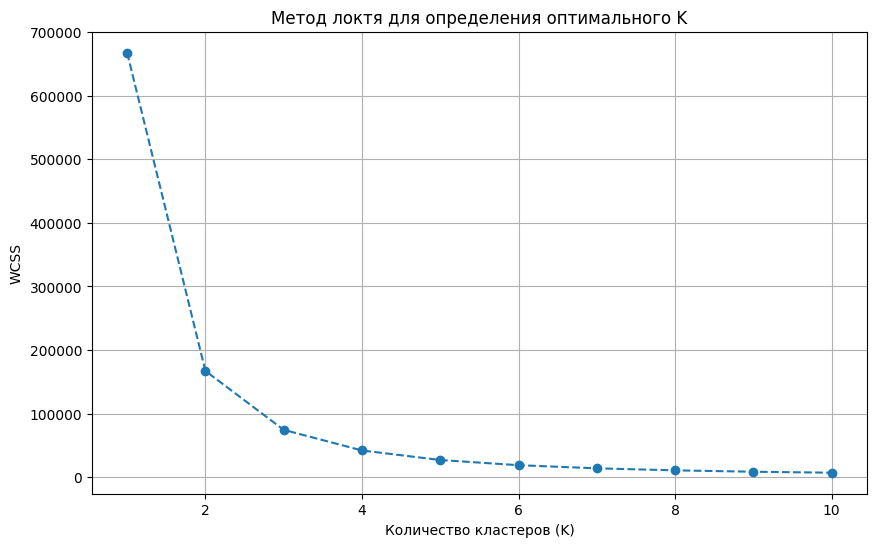

In [ ]:
wcss = [] # Сумма квадратов внутрикластерных расстояний
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Метод локтя для определения оптимального K')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_preprocessed)
df['KMeans_Cluster'] = clusters

display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


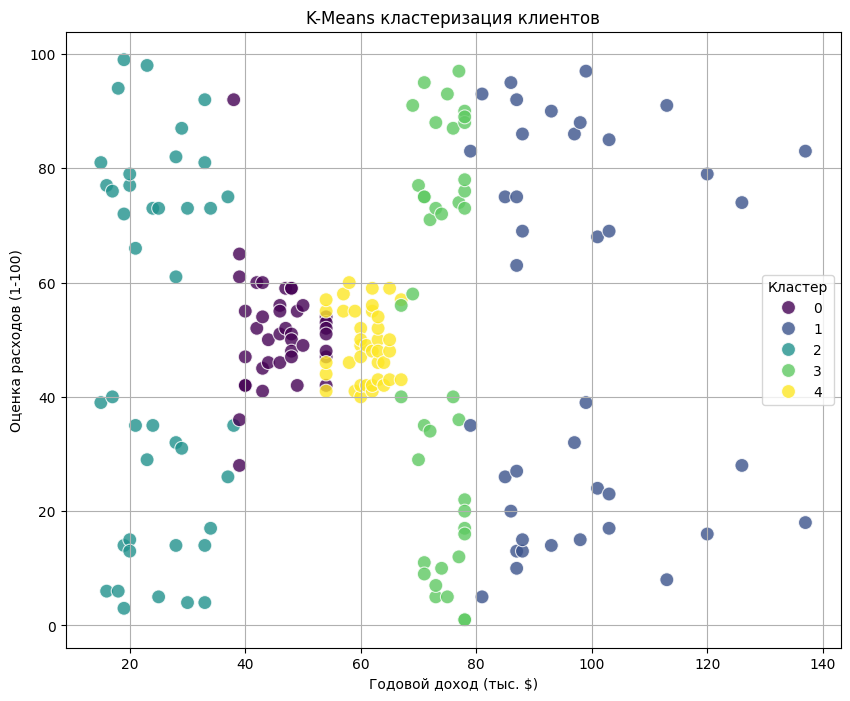

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='viridis',
    data=df,
    s=100, # размер точек
    alpha=0.8
)
plt.title('K-Means кластеризация клиентов')
plt.xlabel('Годовой доход (тыс. $)')
plt.ylabel('Оценка расходов (1-100)')
plt.grid(True)
plt.legend(title='Кластер')
plt.show()

### Глубокая вложенная кластеризация (DEC)

#### 1. Настройка автокодировщика для DEC

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Размерность входных данных - это количество признаков после предварительной обработки
input_dim = X_preprocessed.shape[1]

# Латентная размерность (embedding_dim) является гиперпараметром
embedding_dim = 10

encoder_inputs = Input(shape=(input_dim,))
x = Dense(500, activation='relu')(encoder_inputs)
x = Dense(500, activation='relu')(x)
x = Dense(2000, activation='relu')(x)
encoder_outputs = Dense(embedding_dim, activation='linear', name='embedding')(x)
encoder = Model(encoder_inputs, encoder_outputs, name='encoder')

# Define the Decoder
decoder_inputs = Input(shape=(embedding_dim,))
x = Dense(2000, activation='relu')(decoder_inputs)
x = Dense(500, activation='relu')(x)
x = Dense(500, activation='relu')(x)
decoder_outputs = Dense(input_dim, activation='linear')(x) # Функция активации выходного слоя может быть линейной для масштабированных данных
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

# Define the Autoencoder
autoencoder_outputs = decoder(encoder(encoder_inputs))
autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Сводка автокодировщика:")
autoencoder.summary()
print("\nСводка кодировщика:")
encoder.summary()
print("\nСводка декодировщика:")
decoder.summary()

Сводка автокодировщика:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 10)             │     1,276,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 6)              │     1,276,006 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,552,016 (9.74 MB)

 Trainable params: 2,552,016 (9.74 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2000)           │        22,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │     1,000,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         3,006 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,006 (4.87 MB)

 Trainable params: 1,276,006 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

#### 2. Предварительное обучение автокодировщика

In [ ]:
# Предварительно обучаем автокодировщик
autoencoder.fit(X_preprocessed, X_preprocessed, batch_size=256, epochs=50, verbose=1)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 2230.0786
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 1836.8022
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 703.3455
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 208.8015
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 204.9736
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 28.7687
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 168.2374
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 154.0416
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 30.7554
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 36.9146
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 120.5507
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 26.9905
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 12.9433
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 61.9777
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 61.19

#### 3. Инициализация центров кластеров и определение модели DEC

In [ ]:
from sklearn.cluster import KMeans
from tensorflow.keras import backend as K

# Получаем представления в латентном пространстве от предварительно обученного кодировщика
X_latent = encoder.predict(X_preprocessed)

# Инициализируем центры кластеров с использованием K-Means в латентном пространстве
n_clusters = 5 # Используем то же количество кластеров, что и для K-Means для сравнения
kmeans_latent = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
y_pred_kmeans = kmeans_latent.fit_predict(X_latent)
dec_cluster_centers = kmeans_latent.cluster_centers_

# Определяем слой кластеризации DEC
class ClusteringLayer(tf.keras.layers.Layer):
    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.clusters = None

    def build(self, input_shape):
        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_shape[1]),
            initializer='glorot_uniform',
            name='clustering_centers'
        )
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    def call(self, inputs):
        # Вычисление Q-распределения (t-распределения Стьюдента)
        q = 1.0 / (1.0 + (K.sum(K.square(K.expand_dims(inputs, axis=1) - self.clusters), axis=2) / self.alpha))
        q **= (self.alpha + 1.0) / 2.0
        q = K.transpose(K.transpose(q) / K.sum(q, axis=1))
        return q

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.n_clusters)

# Создаем модель DEC
dec_inputs = Input(shape=(input_dim,))
dec_embedding = encoder(dec_inputs)
dec_outputs = ClusteringLayer(n_clusters, weights=[dec_cluster_centers], name='clustering')(dec_embedding)
dec_model = Model(inputs=dec_inputs, outputs=dec_outputs, name='DEC_model')

dec_model.summary()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Model: "DEC_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 10)             │     1,276,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clustering (ClusteringLayer)    │ (None, 5)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,060 (4.87 MB)

 Trainable params: 1,276,060 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

#### 4. Компиляция и обучение модели DEC

In [ ]:
def target_distribution(q):
    weight = q ** 2 / K.sum(q, axis=0)
    return K.transpose(K.transpose(weight) / K.sum(weight, axis=1))

# Компилируем модель DEC
dec_model.compile(optimizer=Adam(learning_rate=0.001), loss='kld') # Дивергенция Кульбака-Лейблера

# Параметры обучения
maxiter = 2000 # Количество итераций для обучения
update_interval = 140 # Обновляем целевое распределение каждые `update_interval` итераций
tol = 1e-3 # Допуск для критерия остановки

# Цикл обучения для DEC
loss_history = []
index_array = np.arange(X_preprocessed.shape[0])
# Инициализируем y_pred_last, чтобы избежать UnboundLocalError в первой итерации
y_pred_last = np.copy(y_pred_kmeans) # Используем предсказания K-Means в латентном пространстве в качестве начальных предсказаний

for ite in range(maxiter):
    if ite % update_interval == 0:
        q = dec_model.predict(X_preprocessed, verbose=0)
        p = target_distribution(q)  # Обновляем целевое распределение

        # Оцениваем производительность кластеризации
        y_pred = q.argmax(1)
        if ite > 0 and np.sum(np.abs(y_pred_last - y_pred)) / y_pred.shape[0] < tol:
            print(f'Критерий остановки выполнен, сходимость на итерации {ite}')
            break
        y_pred_last = np.copy(y_pred)

    # Обучаем на батче
    idx = index_array[ (ite * 256) % X_preprocessed.shape[0]: min((ite * 256) % X_preprocessed.shape[0] + 256, X_preprocessed.shape[0])]
    # Преобразуем idx в тензор TensorFlow для правильной индексации с tf.gather
    idx_tf = tf.convert_to_tensor(idx, dtype=tf.int32)
    # Используем tf.gather для надежной индексации X_preprocessed (массив NumPy) и p (тензор tf.Tensor)
    loss = dec_model.train_on_batch(x=tf.gather(tf.constant(X_preprocessed, dtype=tf.float32), idx_tf), y=tf.gather(p, idx_tf))
    loss_history.append(loss)

    if ite % 200 == 0:
        print(f'Итерация {ite}, Потери: {loss:.4f}')

print("Обучение DEC завершено.")

# Получаем окончательные назначения кластеров из DEC
q = dec_model.predict(X_preprocessed, verbose=0)
dec_clusters = q.argmax(1)
df['DEC_Cluster'] = dec_clusters

display(df.head())

Итерация 0, Потери: 0.0741
Итерация 200, Потери: 0.2980
Итерация 400, Потери: 0.1950
Итерация 600, Потери: 0.1588
Итерация 800, Потери: 0.1462
Итерация 1000, Потери: 0.1388
Итерация 1200, Потери: 0.1336
Итерация 1400, Потери: 0.1351
Итерация 1600, Потери: 0.1284
Итерация 1800, Потери: 0.1298
Обучение DEC завершено.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,DEC_Cluster
0,1,Male,19,15,39,2,2
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,2,2
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,2,2


### Сравнение K-Means и DEC

#### 1. Метрики оценки

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Оценка K-Means
kmeans_silhouette = silhouette_score(X_preprocessed, df['KMeans_Cluster'])
kmeans_davies_bouldin = davies_bouldin_score(X_preprocessed, df['KMeans_Cluster'])
kmeans_calinski_harabasz = calinski_harabasz_score(X_preprocessed, df['KMeans_Cluster'])

print(f"Silhouette Score K-Means: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Score K-Means: {kmeans_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score K-Means: {kmeans_calinski_harabasz:.4f}")

# Оценка DEC
dec_silhouette = silhouette_score(X_preprocessed, df['DEC_Cluster'])
dec_davies_bouldin = davies_bouldin_score(X_preprocessed, df['DEC_Cluster'])
dec_calinski_harabasz = calinski_harabasz_score(X_preprocessed, df['DEC_Cluster'])

print(f"\nSilhouette Score DEC: {dec_silhouette:.4f}")
print(f"Davies-Bouldin Score DEC: {dec_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score DEC: {dec_calinski_harabasz:.4f}")

Silhouette Score K-Means: 0.5418
Davies-Bouldin Score K-Means: 0.5116
Calinski-Harabasz Score K-Means: 1148.4955

Silhouette Score DEC: 0.4999
Davies-Bouldin Score DEC: 0.5379
Calinski-Harabasz Score DEC: 962.0454


#### 2. Визуализация кластеров DEC

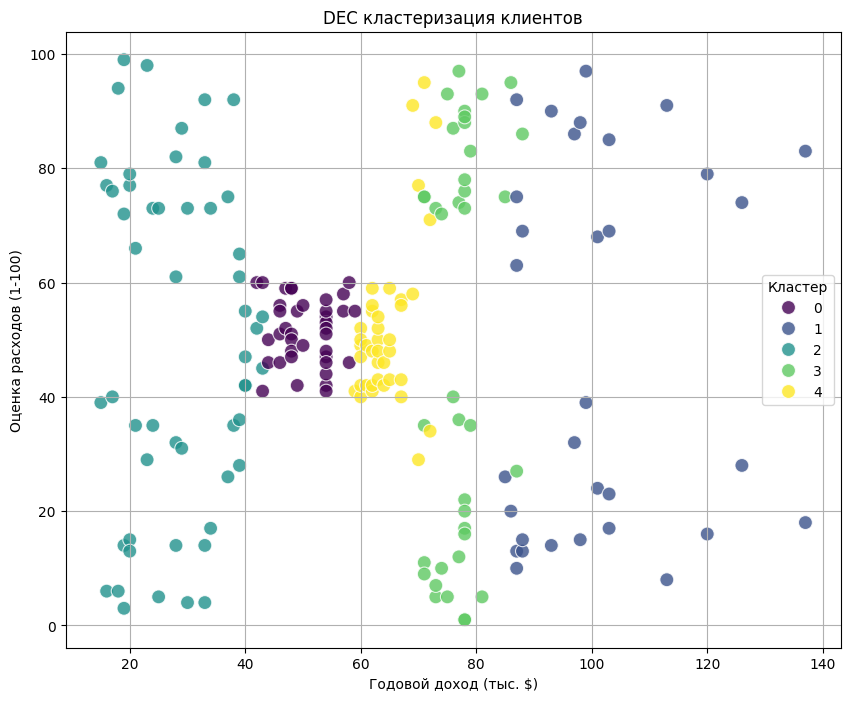

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DEC_Cluster',
    palette='viridis',
    data=df,
    s=100, # размер точек
    alpha=0.8
)
plt.title('DEC кластеризация клиентов')
plt.xlabel('Годовой доход (тыс. $)')
plt.ylabel('Оценка расходов (1-100)')
plt.grid(True)
plt.legend(title='Кластер')
plt.show()

Если сравнивать визуализацию данных, можно заметить, что DEC лучше проработал границу между 0 и 2 кластерами, однако хуже справился с границей кластеров 3 и 4.

Сравнение на основе метрик:
- **Silhouette Score**: Измеряет, насколько объект похож на свой собственный кластер по сравнению с другими кластерами. Более высокие значения указывают на лучше определенные кластеры.
- **Davies-Bouldin Score**: Измеряет среднее отношение сходства каждого кластера с его наиболее похожим кластером. Более низкие значения указывают на лучшую кластеризацию.
- **Calinski-Harabasz Score**: Измеряет отношение суммы дисперсии между кластерами и внутрикластерной дисперсии. Более высокие значения указывают на лучше определенные кластеры.

По метрикам текущая реализация DEC проигрывает текущей реализации К-means.